In [ ]:
"""
Dermalytix — EfficientNetB0 Training Script (Colab)
=====================================================
Classes : Acne, Dark circles, dark spots, dry, normal, oily, wrinkles:FINE LINES
Train   : 5126 images
Val     : 469  images
Model   : EfficientNetB0 pretrained on ImageNet, fine-tuned

Strategy:
  Phase 1 (epochs 1–5)  : freeze base, train classifier head only
  Phase 2 (epochs 6–15) : unfreeze last 3 layers, lower LR
  Phase 3 (epochs 16–20): unfreeze fully if val accuracy < 80%

Saves best model to Drive automatically.
"""

'\nDermalytix — EfficientNetB0 Training Script (Colab)\n=====================================================\nClasses : Acne, Dark circles, dark spots, dry, normal, oily, wrinkles:FINE LINES\nTrain   : 5126 images\nVal     : 469  images\nModel   : EfficientNetB0 pretrained on ImageNet, fine-tuned\n\nStrategy:\n  Phase 1 (epochs 1–5)  : freeze base, train classifier head only\n  Phase 2 (epochs 6–15) : unfreeze last 3 layers, lower LR\n  Phase 3 (epochs 16–20): unfreeze fully if val accuracy < 80%\n\nSaves best model to Drive automatically.\n'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

# Find the exact path of DATASET_SPLIT
for root, dirs, files in os.walk("/content/drive"):
    for d in dirs:
        if "DATASET_SPLIT" in d:
            print(repr(os.path.join(root, d)))

'/content/drive/MyDrive/DATASET_SPLIT'


In [5]:
import subprocess
subprocess.run(["pip", "install", "torch", "torchvision", "scikit-learn", "matplotlib", "tqdm", "-q"])

import os, time, copy, torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU!'}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch : 2.10.0+cu128
GPU     : Tesla T4


In [ ]:

# ── CELL 2: Config ────────────────────────────────────────
# Use EXACTLY what Cell 2 printed above
SPLIT_DIR = "/content/drive/MyDrive/DATASET_SPLIT"   # update if Cell 2 shows different
SAVE_DIR  = "/content/drive/MyDrive/DERMALYTIX_MODEL"
os.makedirs(SAVE_DIR, exist_ok=True)

# Verify it works
print("SPLIT_DIR exists:", os.path.exists(SPLIT_DIR))
for split in ["train", "val", "test"]:
    p = os.path.join(SPLIT_DIR, split)
    total = sum(len(os.listdir(os.path.join(p, c))) for c in os.listdir(p))
    print(f"  {split}: {total} images")


SPLIT_DIR exists: True
  train: 5126 images
  val: 469 images
  test: 469 images


In [ ]:
import os, torch

SPLIT_DIR     = "/content/drive/MyDrive/DATASET_SPLIT"
SAVE_DIR      = "/content/drive/MyDrive/DERMALYTIX_MODEL"
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_CLASSES   = 7
BATCH_SIZE    = 32
IMG_SIZE      = 224
SEED          = 42
torch.manual_seed(SEED)

PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 10
PHASE3_EPOCHS = 5

CLASS_NAMES = [
    "Acne", "Dark circles", "dark spots",
    "dry", "normal", "oily", "wrinkles:FINE LINES"
]

print("✅ Config loaded")
print("SPLIT_DIR exists:", os.path.exists(SPLIT_DIR))

✅ Config loaded
SPLIT_DIR exists: True


In [ ]:
# ── CELL 3: Data loaders ──────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, "train"), train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(SPLIT_DIR, "val"),   val_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(SPLIT_DIR, "test"),  val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nDataset loaded:")
print(f"  Train : {len(train_dataset)} images")
print(f"  Val   : {len(val_dataset)} images")
print(f"  Test  : {len(test_dataset)} images")
print(f"  Classes ({len(train_dataset.classes)}): {train_dataset.classes}")


Dataset loaded:
  Train : 5126 images
  Val   : 469 images
  Test  : 469 images
  Classes (7): ['Acne', 'Dark circles', 'dark spots', 'dry', 'normal', 'oily', 'wrinkles:FINE LINES']


In [6]:
# ── CELL 4: Build model ───────────────────────────────────
def build_model(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze ALL base layers first
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head for our 7 classes
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )

    return model.to(DEVICE)

model = build_model(NUM_CLASSES)
print(f"\nModel built: EfficientNetB0")
print(f"  Trainable params (head only): "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")



NameError: name 'NUM_CLASSES' is not defined

In [ ]:
# ── CELL 5: Training helpers ──────────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


def unfreeze_last_n(model, n):
    """Unfreeze last n blocks of EfficientNet features."""
    layers = list(model.features.children())
    for layer in layers[-n:]:
        for param in layer.parameters():
            param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Unfroze last {n} blocks → {trainable:,} trainable params")


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Unfroze ALL layers → {trainable:,} trainable params")

In [ ]:



# ── CELL 6: Training loop ─────────────────────────────────
def run_training():
    criterion    = nn.CrossEntropyLoss()
    history      = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_val_acc = 0.0
    best_weights = None

    # ── PHASE 1: Head only ──
    print("\n" + "="*55)
    print("  PHASE 1 — Training classifier head only")
    print(f"  Epochs : {PHASE1_EPOCHS}  |  LR : 1e-3")
    print("="*55)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    for epoch in range(1, PHASE1_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"  Epoch {epoch:02d}/{PHASE1_EPOCHS} | "
              f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"Val loss {vl_loss:.4f} acc {vl_acc:.3f} | "
              f"{'⭐ best' if vl_acc == best_val_acc else ''} "
              f"({time.time()-t0:.0f}s)")

    # ── PHASE 2: Unfreeze last 3 blocks ──
    print("\n" + "="*55)
    print("  PHASE 2 — Unfreezing last 3 feature blocks")
    print(f"  Epochs : {PHASE2_EPOCHS}  |  LR : 1e-4")
    print("="*55)
    unfreeze_last_n(model, 3)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS)

    for epoch in range(1, PHASE2_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"  Epoch {epoch:02d}/{PHASE2_EPOCHS} | "
              f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"Val loss {vl_loss:.4f} acc {vl_acc:.3f} | "
              f"{'⭐ best' if vl_acc == best_val_acc else ''} "
              f"({time.time()-t0:.0f}s)")

    # ── PHASE 3: Unfreeze all (only if val acc < 80%) ──
    if best_val_acc < 0.80:
        print("\n" + "="*55)
        print(f"  PHASE 3 — Val acc {best_val_acc:.1%} < 80% → unfreezing all layers")
        print(f"  Epochs : {PHASE3_EPOCHS}  |  LR : 1e-5")
        print("="*55)
        unfreeze_all(model)
        optimizer = optim.Adam(model.parameters(), lr=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE3_EPOCHS)

        for epoch in range(1, PHASE3_EPOCHS + 1):
            t0 = time.time()
            tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
            vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
            scheduler.step()

            history["train_loss"].append(tr_loss)
            history["val_loss"].append(vl_loss)
            history["train_acc"].append(tr_acc)
            history["val_acc"].append(vl_acc)

            if vl_acc > best_val_acc:
                best_val_acc = vl_acc
                best_weights = copy.deepcopy(model.state_dict())

            print(f"  Epoch {epoch:02d}/{PHASE3_EPOCHS} | "
                  f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
                  f"Val loss {vl_loss:.4f} acc {vl_acc:.3f} | "
                  f"{'⭐ best' if vl_acc == best_val_acc else ''} "
                  f"({time.time()-t0:.0f}s)")
    else:
        print(f"\n  ✅ Val acc {best_val_acc:.1%} ≥ 80% — skipping Phase 3")

    # ── Save best model ──
    model.load_state_dict(best_weights)
    save_path = os.path.join(SAVE_DIR, "dermalytix_best.pth")
    torch.save({
        "model_state_dict": best_weights,
        "class_names":      CLASS_NAMES,
        "val_acc":          best_val_acc,
        "num_classes":      NUM_CLASSES,
    }, save_path)
    print(f"\n  ✅ Best model saved → {save_path}")
    print(f"  🏆 Best val accuracy : {best_val_acc:.2%}")

    return history

history = run_training()


  PHASE 1 — Training classifier head only
  Epochs : 5  |  LR : 1e-3
  Epoch 01/5 | Train loss 1.1289 acc 0.573 | Val loss 0.6492 acc 0.755 | ⭐ best (972s)
  Epoch 02/5 | Train loss 0.8438 acc 0.676 | Val loss 0.6162 acc 0.772 | ⭐ best (35s)
  Epoch 03/5 | Train loss 0.7711 acc 0.709 | Val loss 0.5371 acc 0.819 | ⭐ best (34s)
  Epoch 04/5 | Train loss 0.6907 acc 0.734 | Val loss 0.4694 acc 0.836 | ⭐ best (35s)
  Epoch 05/5 | Train loss 0.6541 acc 0.758 | Val loss 0.4759 acc 0.840 | ⭐ best (34s)

  PHASE 2 — Unfreezing last 3 feature blocks
  Epochs : 10  |  LR : 1e-4
  Unfroze last 3 blocks → 3,485,475 trainable params
  Epoch 01/10 | Train loss 0.5670 acc 0.784 | Val loss 0.4205 acc 0.842 | ⭐ best (35s)
  Epoch 02/10 | Train loss 0.4068 acc 0.852 | Val loss 0.3104 acc 0.881 | ⭐ best (36s)
  Epoch 03/10 | Train loss 0.3291 acc 0.877 | Val loss 0.2688 acc 0.898 | ⭐ best (35s)
  Epoch 04/10 | Train loss 0.2646 acc 0.906 | Val loss 0.2490 acc 0.904 | ⭐ best (37s)
  Epoch 05/10 | Train lo

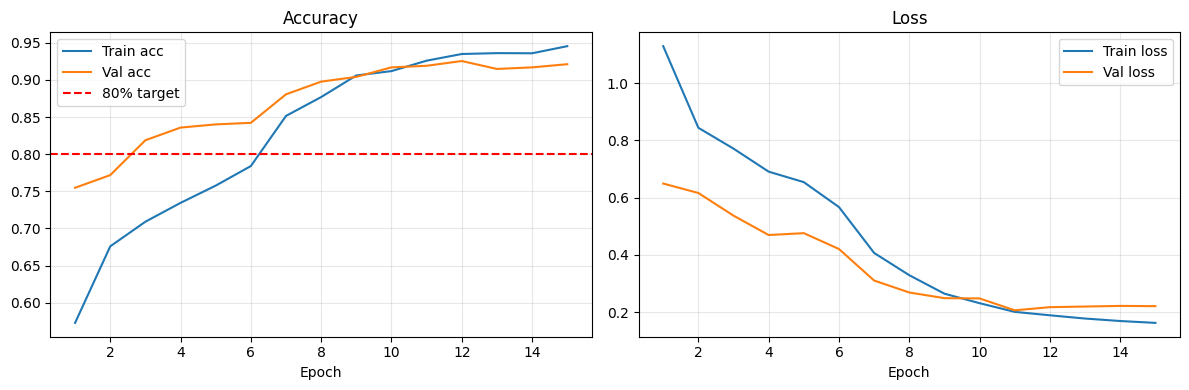

  Plot saved → /content/drive/MyDrive/DERMALYTIX_MODEL/training_curves.png


In [ ]:
# ── CELL 7: Plot training curves ──────────────────────────
def plot_history(history):
    epochs = range(1, len(history["train_acc"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_acc"], label="Train acc")
    ax1.plot(epochs, history["val_acc"],   label="Val acc")
    ax1.axhline(0.8, color="red", linestyle="--", label="80% target")
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_loss"], label="Train loss")
    ax2.plot(epochs, history["val_loss"],   label="Val loss")
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(SAVE_DIR, "training_curves.png")
    plt.savefig(plot_path, dpi=120)
    plt.show()
    print(f"  Plot saved → {plot_path}")

plot_history(history)

In [ ]:
# ── CELL 8: Final evaluation on test set ─────────────────
def evaluate_test():
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print("\n" + "="*55)
    print("  FINAL TEST SET EVALUATION")
    print("="*55)
    print(classification_report(
        all_labels, all_preds,
        target_names=train_dataset.classes,
        digits=3
    ))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(train_dataset.classes, rotation=35, ha="right")
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(train_dataset.classes)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    ax.set_title("Confusion Matrix — Test Set")
    plt.colorbar(im); plt.tight_layout()
    cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
    plt.savefig(cm_path, dpi=120); plt.show()
    print(f"  Confusion matrix saved → {cm_path}")

evaluate_test()

NameError: name 'model' is not defined

In [ ]:
# See what the model is confusing oily and normal with
import torch
import numpy as np

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Print confusion for oily and normal only
from sklearn.metrics import confusion_matrix
import pandas as pd

classes = train_dataset.classes
cm = confusion_matrix(all_labels, all_preds)
df = pd.DataFrame(cm, index=classes, columns=classes)
print("Full confusion matrix:")
print(df.to_string())
print("\nOily row   → what oily images got predicted as")
print(df.loc["oily"])
print("\nNormal row → what normal images got predicted as")
print(df.loc["normal"])

Full confusion matrix:
                     Acne  Dark circles  dark spots  dry  normal  oily  wrinkles:FINE LINES
Acne                  187             0           3    0       0     0                    0
Dark circles            0            31           0    0       0     0                    0
dark spots              1             1          42    0       0     0                    0
dry                     0             1           0   76      12    14                    3
normal                  0             0           0    0      22     0                    1
oily                    0             0           0    0       0    16                    0
wrinkles:FINE LINES     0             3           1    0       0     0                   55

Oily row   → what oily images got predicted as
Acne                    0
Dark circles            0
dark spots              0
dry                     0
normal                  0
oily                   16
wrinkles:FINE LINES     0
Name: oily,

In [ ]:
# ── FIX: Weighted loss retrain — fix dry/oily/normal confusion ──────────
import torch, copy, time
import torch.nn as nn
import torch.optim as optim

# Higher weight = model punished more for getting that class wrong
# Order: Acne, Dark circles, dark spots, dry, normal, oily, wrinkles
class_weights = torch.tensor([
    1.0,  # Acne         — perfect, no change
    1.0,  # Dark circles — perfect, no change
    1.0,  # dark spots   — good, no change
    2.0,  # dry          — confusing with oily/normal → penalize
    2.5,  # normal       — small class → penalize more
    3.0,  # oily         — smallest + most confused → highest penalty
    1.0,  # wrinkles     — good, no change
]).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

best_val_acc = 0.0
best_weights_fix = None

print("="*55)
print("  FIXING — Weighted retrain (10 epochs)")
print("  Targeting: dry / oily / normal confusion")
print("="*55)

for epoch in range(1, 11):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights_fix = copy.deepcopy(model.state_dict())
        star = "⭐ best"
    else:
        star = ""

    print(f"  Epoch {epoch:02d}/10 | "
          f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"Val loss {vl_loss:.4f} acc {vl_acc:.3f} | "
          f"{star} ({time.time()-t0:.0f}s)")

# Load best weights from this fix run
model.load_state_dict(best_weights_fix)

# Save updated model to Drive
save_path = os.path.join(SAVE_DIR, "dermalytix_best_v2.pth")
torch.save({
    "model_state_dict": best_weights_fix,
    "class_names":      CLASS_NAMES,
    "val_acc":          best_val_acc,
    "num_classes":      NUM_CLASSES,
}, save_path)
print(f"\n  ✅ Fixed model saved → {save_path}")

# Evaluate on test set
print("\n  Running final evaluation...")
evaluate_test()

NameError: name 'DEVICE' is not defined

In [7]:
# ── Reload model from Drive ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
import os

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "/content/drive/MyDrive/DERMALYTIX_MODEL"
SPLIT_DIR = "/content/drive/MyDrive/DATASET_SPLIT"

# Rebuild model architecture
def build_model(num_classes=7):
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    return model

# Load saved weights
checkpoint = torch.load(
    os.path.join(SAVE_DIR, "dermalytix_best_v2.pth"),
    map_location=DEVICE
)
model = build_model(num_classes=7)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

# Load class names from dataset
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "train"), val_transforms
)

print("✅ Model loaded successfully!")
print(f"   Classes: {train_dataset.classes}")
print(f"   Device : {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded successfully!
   Classes: ['Acne', 'Dark circles', 'dark spots', 'dry', 'normal', 'oily', 'wrinkles:FINE LINES']
   Device : cuda


In [10]:
# ── User-friendly label mapping ───────────────────────────

LABEL_MAP = {
    "Acne": {
        "display":     "Acne / Pimples / Breakouts",
        "description": "Active acne lesions including papules, pustules or comedones",
        "icon":        "🔴"
    },
    "Dark circles": {
        "display":     "Dark Circles / Periorbital Hyperpigmentation",
        "description": "Darkening of the skin under and around the eyes",
        "icon":        "👁️"
    },
    "dark spots": {
        "display":     "Dark Spots / Hyperpigmentation / Post-Acne Marks",
        "description": "Uneven skin tone, dark patches or marks left after acne or sun damage",
        "icon":        "🟤"
    },
    "dry": {
        "display":     "Dry Skin / Dehydrated Skin",
        "description": "Skin lacking moisture, may feel tight, flaky or rough",
        "icon":        "🏜️"
    },
    "normal": {
        "display":     "Normal / Balanced Skin",
        "description": "Well-balanced skin with no major concerns",
        "icon":        "✨"
    },
    "oily": {
        "display":     "Oily Skin / Seborrhoea",
        "description": "Excess sebum production causing shine and enlarged pores",
        "icon":        "💧"
    },
    "wrinkles": {
        "display":     "Wrinkles / Fine Lines / Ageing Skin",
        "description": "Signs of ageing including fine lines, wrinkles and loss of elasticity",
        "icon":        "〰️"
    },
}

def get_display_label(raw_class):
    return LABEL_MAP.get(raw_class, {
        "display":     raw_class,
        "description": "",
        "icon":        "🔍"
    })

# Test it
print("Label mapping test:")
for cls in train_dataset.classes:
    info = get_display_label(cls)
    print(f"  {info['icon']}  {cls:<25} → {info['display']}")

Label mapping test:
  🔴  Acne                      → Acne / Pimples / Breakouts
  👁️  Dark circles              → Dark Circles / Periorbital Hyperpigmentation
  🟤  dark spots                → Dark Spots / Hyperpigmentation / Post-Acne Marks
  🏜️  dry                       → Dry Skin / Dehydrated Skin
  ✨  normal                    → Normal / Balanced Skin
  💧  oily                      → Oily Skin / Seborrhoea
  🔍  wrinkles:FINE LINES       → wrinkles:FINE LINES


In [12]:
# ── Test model with a real image (with label mapping) ─────
from PIL import Image
import torchvision.transforms as transforms
import torch.nn.functional as F
from google.colab import files

# Upload an image from your computer
print("Upload a skin image to test:")
uploaded = files.upload()

# Load and preprocess
img_path = list(uploaded.keys())[0]
img = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
img_tensor = transform(img)

# Predict
model.eval()
with torch.no_grad():
    output = model(img_tensor.unsqueeze(0).to(DEVICE))
    probs  = F.softmax(output, dim=1)[0]

# Top prediction
top_prob, top_idx = probs.max(0)
top_class = train_dataset.classes[top_idx.item()]
top_info  = get_display_label(top_class)

# Show results
print("\n" + "="*52)
print("  DERMALYTIX PREDICTION RESULTS")
print("="*52)
print(f"\n  {top_info['icon']}  {top_info['display']}")
print(f"  📊 Confidence  : {top_prob.item()*100:.1f}%")
print(f"  📝 Description : {top_info['description']}")

# All class probabilities
print("\n  All classes:")
for cls, prob in zip(train_dataset.classes, probs):
    info = get_display_label(cls)
    bar  = "█" * int(prob.item() * 30)
    print(f"  {info['icon']} {cls:<22} {prob.item()*100:5.1f}%  {bar}")

# Uncertainty check
if top_class in ["oily", "normal"] and top_prob.item() < 0.65:
    top2_probs, top2_idxs = probs.topk(2)
    c1 = get_display_label(train_dataset.classes[top2_idxs[0].item()])["display"]
    c2 = get_display_label(train_dataset.classes[top2_idxs[1].item()])["display"]
    print(f"\n  ⚠️  Low confidence — possibly:")
    print(f"      • {c1}")
    print(f"      • {c2}")
    print(f"  💬 Please consult a dermatologist for accurate diagnosis")
else:
    print(f"\n  ✅ High confidence prediction")

print("="*52)

Upload a skin image to test:


Saving IMG_4402 (1).jpeg to IMG_4402 (1).jpeg

  DERMALYTIX PREDICTION RESULTS

  🟤  Dark Spots / Hyperpigmentation / Post-Acne Marks
  📊 Confidence  : 96.5%
  📝 Description : Uneven skin tone, dark patches or marks left after acne or sun damage

  All classes:
  🔴 Acne                     1.7%  
  👁️ Dark circles             0.8%  
  🟤 dark spots              96.5%  ████████████████████████████
  🏜️ dry                      0.9%  
  ✨ normal                   0.0%  
  💧 oily                     0.0%  
  🔍 wrinkles:FINE LINES      0.0%  

  ✅ High confidence prediction


In [8]:
# ── Option A: Confidence threshold fix for oily/normal ──
import torch
import torch.nn.functional as F

def predict_with_confidence(image_tensor, threshold=0.65):
    """
    Returns prediction with confidence.
    If top class is oily/normal and confidence < threshold,
    returns a soft combined label instead.
    """
    model.eval()
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0).to(DEVICE))
        probs  = F.softmax(output, dim=1)[0]

    top_prob, top_idx = probs.max(0)
    top_class = train_dataset.classes[top_idx.item()]
    top_prob  = top_prob.item()

    # Soft prediction for weak classes
    WEAK_CLASSES = ["oily", "normal"]
    if top_class in WEAK_CLASSES and top_prob < threshold:
        # Get top 2 predictions
        top2_probs, top2_idxs = probs.topk(2)
        c1 = train_dataset.classes[top2_idxs[0].item()]
        c2 = train_dataset.classes[top2_idxs[1].item()]
        return {
            "prediction":  f"possibly {c1} or {c2}",
            "confidence":  round(top_prob, 3),
            "is_uncertain": True,
            "advice": "Results unclear — please consult a dermatologist for accurate diagnosis"
        }

    return {
        "prediction":   top_class,
        "confidence":   round(top_prob, 3),
        "is_uncertain": False,
        "advice": None
    }

# Test it
# Test it
print("✅ Confidence threshold predictor ready")

from PIL import Image
import torchvision.transforms as transforms
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

img = Image.open(img_path).convert("RGB")
img_tensor = transform(img)

result = predict_with_confidence(img_tensor)
print("\nExample output:")
print(result)

✅ Confidence threshold predictor ready


Saving IMG_4401 (1).jpeg to IMG_4401 (1) (2).jpeg

Example output:
{'prediction': 'dark spots', 'confidence': 0.528, 'is_uncertain': False, 'advice': None}
